## Модель для предсказания вероятности клика на рекламное объявление

Выполнила: Тулянцева Альбина

Дата: 13.04.2026

**Описание проекта**: Бизнес-модель Advandex и аукционы напрямую зависят от достоверности предсказанных вероятностей. Некорректные прогнозы ведут к прямым финансовым потерям.
Если модель постоянно завышает предсказания, то платформа будет переплачивать за показы и выигрывать аукционы по невыгодной цене. Так, при реальной кликабельности в 5% предсказанное значение CTR, равное 20%, сожжёт бюджет рекламодателей и подорвёт их доверие к платформе.
Если модель пессимистично оценивает перспективные объявления, предсказывая шанс клика в 5% вместо реальных 20%, платформа будет проигрывать аукционы, упуская потенциальный доход от кликов.
**Цель**: построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление, и добиться, чтобы предсказанные вероятности кликов максимально точно соответствовали их реальной частоте.

**Информация о данных**:
Данные содержат информацию о показе рекламных баннеров и действиях пользователей за фиксированный временной промежуток. Данные представлены в виде готовой аналитической витрины. Это означает, что для каждого показа рекламного баннера уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки. Каждая строка соответствует одному уникальному событию показа рекламы. Все признаки предварительно обработаны и представлены в виде числовых и категориальных значений. Датасет прошёл предварительную обработку для обеспечения анонимности и сохранности данных.

**Данные**:

id — уникальный идентификатор записи о показе баннера;

hour — час, в который был показан баннер, в формате YYMMDDHH;

site_id — идентификатор веб-сайта, на котором был показан баннер;

site_domain — домен веб-сайта;

site_category — тематическая категория веб-сайта;

app_id — идентификатор рекламируемого мобильного приложения;

app_domain — домен рекламируемого приложения;

app_category — категория рекламируемого приложения;

device_id — идентификатор браузера или устройства;

device_ip — IP-адрес устройства;

device_model — модель устройства;

device_type — тип устройства пользователя: например, смартфон, планшет, ПК;

device_conn_type — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G;

banner_pos — позиция баннера на веб-странице;

C1 — анонимизированный признак, характеризующий контекст показа;

C14 — C21 — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона;

ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10 — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;

ml_feature_2, ml_feature_7 — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

**Целевая переменная**: click — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.

**Метрики**:
Для оценки в этом проекте будут исползоваться три основные метрики: 
- PR-AUC - основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы, но при этом оно критически важно для бизнеса.
- Log Loss позволит оценить точность предсказанных вероятностей. Это важно, чтобы оптимизировать ставки на аукционах, где от достоверности вероятностей напрямую зависит эффективность расходов рекламодателей.
- Оценка Бриера измеряет и точность, и калибровку модели, то есть общее соответствие прогнозов реальным результатам. Для платформы это имеет прямое финансовое значение, так как ошибки в прогнозах приводят либо к переплатам, либо к упущенной выгоде.

Дополнительные метрики оценки модели:
- Precision — точность предсказания кликов.
- Recall — полнота охвата реальных кликов.
- F1-score — балансирует точность и полноту.
- Для детального анализа калибровки пригодятся метрики ECE и MCE. Они оценивают, насколько хорошо откалиброваны предсказанные вероятности по разным диапазонам.

**Структура проекта**:
1. Подготовка среды и загрузка данных
2. Исследовательский анализ данных(EDA)
3. Разделение данных на выборки
4. Предобработка данных - построение пайплайнов
5. Отбор признаков
6. Обучение базовой модели
7. Подбор гиперпараметров: GridSearch с кросс-валидацией
8. Финальная модель
9. Калибровка модели
10. Оценка качества калибровки
11. Финальный отчет и выводы
12. Сохранение модели для продакшена

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [1]:
%%writefile requirements.txt
pandas==1.5.3
matplotlib==3.7.2
seaborn==0.12.2
numpy ==1.22.4
scikit-learn==1.3.0
scipy==1.10.1
phik==0.12.3
joblib==1.3.2

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt -q

In [3]:
#Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Импорт модулей библиотеки scikit-learn
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, log_loss, average_precision_score, brier_score_loss
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import VarianceThreshold

#Импорт scipy
from scipy.special import expit

#Импорт phik
!pip install phik -q
from phik import phik_matrix

#Импорт joblib
import joblib
from datetime import datetime

#Фиксируем random_state
RANDOM_STATE = 42

In [4]:
#Загрузка датасета
df = pd.read_csv('/datasets/ds_s16_ad_click_dataset.csv')

In [5]:
#Выведем размерность датасета
df.shape

(50000, 34)

Всего в датасете наблюдается 34 столбца и 50000 строк. Столбцов достаточно много, поэтому нужно будет провести фильтрацию признаков для улучшения работы модели.

In [6]:
#Выводим первые 5 строк
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [7]:
#Выводим последние 5 строк
df.tail()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
49995,9.452834e+18,1,14103023,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,2.471707,A,6.971072,0,0.598654,0.897131,Y,1.102908,-0.063549,0.164935
49996,9.487581e+18,0,14103023,1005,1,0a742914,510bd839,f028772b,ecad2386,7801e8d9,...,0.380915,E,-1.829184,1,0.156171,0.181065,Y,0.136576,0.279587,0.193894
49997,9.895353e+18,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,d36838b1,0e8616ad,...,0.582656,E,-1.839117,1,-0.358271,0.472134,Z,0.385089,-0.094572,0.123317
49998,9.911007e+17,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,3c4b944d,2347f47a,...,-0.502279,B,4.263653,1,-1.567715,-0.997265,Z,-0.314288,0.267059,0.407779
49999,9.965090e+18,0,14103023,1005,1,57fe1b20,5b626596,f028772b,ecad2386,7801e8d9,...,0.078363,B,-5.710199,1,-2.015219,-0.991569,X,0.083858,-0.014856,-0.194617


Датасет успешно выводится, значит загрузка прошла успешно. По первым и последним 5 строкам уже можно заметить, что столбец "C1" может иметь лишь одно значение или это значение доминирует. В дальнейшем нужно будет проверить этот столбец. По столбцу "hour" видно, что датасет предоставлен за промежуток в 9 дней. Какие-то другие закономерности пока не выявляются, выведем информацию о столбцах датасета.

In [8]:
#Выводим информацию о столбцах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

Датасет уже обработанный, поэтому в нем не наблюдается пропусков, однако в дальнейшем нужно проверить распределение признаков, возможно внутри данных есть значения заглушки, которые будут мешать работе модели. 
Интересно, что признаки "device_type" и "device_conn_type", которые должны отображать тип устройства и тип сетевого соединения, представлены в формате int64. Проверим, какие они содержат значения.

In [9]:
#Выводим уникальные значения device_type
df['device_type'].unique()

array([1, 5, 4, 0])

In [10]:
#Выводим уникальные значения device_conn_type
df['device_conn_type'].unique()

array([0, 2, 3, 5])

Эти признаки имеют числовые значения, которые скорее всего соответствуют какому-нибудь категориальному значению. В дальнейшем посмотрим распределение этих признаков. Далее проверим числовые столбцы датасета.

In [11]:
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


Уже по среднему значению целевой переменной можно заметить, что данные распределены неравномерно и намного больше отсутствия кликов. В столбце "C1" первый, второй и третий квартили имеют значение 1005, что говорит о преобладании этого значения в данных. Также в столбце "device_type" преобладает значение 1, а в столбце "device_conn_type" значение 0. Такая аномалия наблюдается во многих столбцах, поэтому изучим их в дальнейшем.

**Общие выводы**: после загрузки данных и их первичного анализа было выявлено в датасете наблюдается 34 столбца и 50000 строк. Столбцов достаточно много, поэтому нужно будет провести фильтрацию признаков для улучшения работы модели. Также по первым и последним 5 строкам уже можно заметить, что столбец "C1" может иметь лишь одно значение или это значение доминирует. В дальнейшем нужно будет проверить этот столбец. По столбцу "hour" видно, что датасет предоставлен за промежуток в 9 дней. Датасет уже обработанный, поэтому в нем не наблюдается пропусков, однако в дальнейшем нужно проверить распределение признаков, возможно внутри данных есть значения заглушки, которые будут мешать работе модели. Признаки "device_type" и "device_conn_type", которые должны отображать тип устройства и тип сетевого соединения, имеют числовые значения, которые скорее всего соответствуют какому-нибудь категориальному значению. В дальнейшем посмотрим распределение этих признаков. Уже по среднему значению целевой переменной можно заметить, что данные распределены неравномерно и намного больше отсутствия кликов. В столбце "C1" первый, второй и третий квартили имеют значение 1005, что говорит о преобладании этого значения в данных. Также в столбце "device_type" преобладает значение 1, а в столбце "device_conn_type" значение 0. Такая аномалия наблюдается во многих столбцах.

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

**2.1 Описание данных**

В данных присутствуют 33 признака и целевая переменная. Из признаков 22 являются числовыми и 11 категориальными. Уже сейчас можно сказать, что некоторые признаки являются неинформативными для модели, так как содержат в себе id. В дальнейшем их нужно будет удалить, чтобы не мешать работе модели. Про пользователя можно сказать, что он намного реже кликает на рекламу, чем игнорирует ее. Построим график, чтобы это проверить.

**2.2 Анализ целевой переменной**

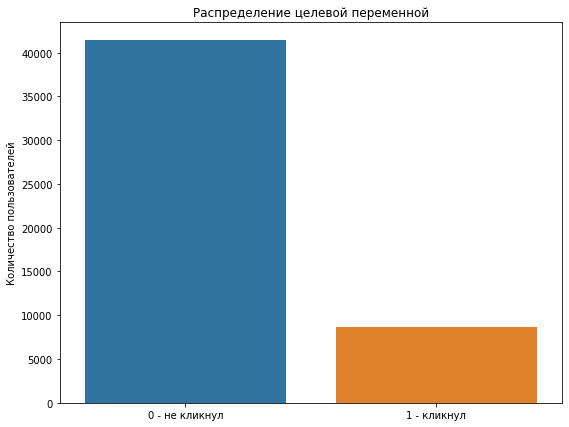

In [12]:
#Построим countplot для визуализации распределения целевой переменной
plt.figure(figsize=(9, 7))
ax = sns.countplot(data=df, x='click')
plt.title('Распределение целевой переменной')
plt.xlabel('')
plt.ylabel('Количество пользователей')

ax.set_xticklabels(['0 - не кликнул', '1 - кликнул'])
plt.show()

In [13]:
#Считаем количество кликнувших и их долю
num_clicked = df['click'].sum()
clicked_ratio = round((num_clicked/len(df))*100, 2)

print(f'Количество кликнувших пользователей: {num_clicked} чел.')
print(f'Процент кликнувших пользователей: {clicked_ratio}%')

Количество кликнувших пользователей: 8603 чел.
Процент кликнувших пользователей: 17.21%


Из 50000 пользователей только 8603 совершили клик, что составляет 17.21% от данных. Это означает, что данные распределены неравномерно и к выбору метрик нужно подходить осторожно. Больше всего к таким данным подойдет в качестве основной метрика PR-AUC, которая работает с несбалансированными данными и поможет заметить клик. 

**2.3 Проверка дубликатов**

In [14]:
#Проверим, есть ли в данных явные дубликаты
len_duplicates = df.duplicated().sum()

print(f'Количество явных дубликатов: {len_duplicates}')

#Считаем дубликаты в связке id и hour
len_duplicates_id_hour = df.duplicated(subset=['id', 'hour']).sum()

print(f'Количество дубликатов в связке id и hour: {len_duplicates_id_hour}')

Количество явных дубликатов: 0
Количество дубликатов в связке id и hour: 0


В данных отсутствуют явные дубликаты, а также дубликаты в связке id и hour.

**2.4 Анализ признаков**

Уже на данном этапе можно сказать, что не все признаки нужны для обучения модели. Из списка признаков стоит исключить "id", "device_id" и "device_ip", так как показывают уникальные значения пользователей и устройств, по которым нельзя найти закономерности, что будет только мешать модели. Удалим эти признаки.

In [15]:
#Удалим ненужные признаки
columns_to_drop = ['id', 'device_id', 'device_ip']

df = df.drop(columns=columns_to_drop)

df.shape

(50000, 31)

Количество столбцов уменьшилось, значит признаки успешно удалены.

**2.5 Анализ пропущенных значений**

In [16]:
#Выведем количество пропусков в каждом столбце
print(df.isna().sum())

click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
ml_feature_1        0
ml_feature_2        0
ml_feature_3        0
ml_feature_4        0
ml_feature_5        0
ml_feature_6        0
ml_feature_7        0
ml_feature_8        0
ml_feature_9        0
ml_feature_10       0
dtype: int64


В данных отсутствуют явные пропуски.

**2.6 Анализ категориальных признаков**

In [17]:
#Проверим уникальные значения в категориальных признаках
for column in ['site_category', 'site_id', 'site_domain', 
               'app_category', 'app_id', 'app_domain',
               'ml_feature_2', 'ml_feature_7', 'device_model']:
    print(f'\nУникальные значения в столбце {column}: {df[column].unique()}')


Уникальные значения в столбце site_category: ['f028772b' '28905ebd' '50e219e0' '3e814130' '335d28a8' '0569f928'
 '76b2941d' 'a818d37a' '75fa27f6' 'f66779e6' '70fb0e29' '72722551'
 'e787de0e' 'c0dd3be3' 'dedf689d' 'bcf865d9' '8fd0aea4' '42a36e14']

Уникальные значения в столбце site_id: ['d9750ee7' '1fbe01fe' '85f751fd' ... '46e56230' 'ed37f65c' 'a4427a7b']

Уникальные значения в столбце site_domain: ['98572c79' 'f3845767' 'c4e18dd6' ... '53175207' '4ebf9b98' '0c34cac9']

Уникальные значения в столбце app_category: ['07d7df22' '0f2161f8' 'cef3e649' 'f95efa07' '8ded1f7a' '75d80bbe'
 'd1327cf5' 'dc97ec06' '09481d60' '879c24eb' '0f9a328c' '4ce2e9fc'
 'fc6fa53d' 'a3c42688' '8df2e842' 'a7fd01ec' '4681bb9d' '2281a340'
 '18b1e0be' '0bfbc358' '79f0b860' '7113d72a']

Уникальные значения в столбце app_id: ['ecad2386' '39cfef32' 'fbbccc58' '5e3f096f' 'cf0327f9' '95b5e741'
 'a0fc55e5' 'd1763ed2' 'bbcfa7a2' '1779deee' '39947756' 'c9d8ce69'
 'c7f29df3' '0acbeaa3' '661aa3aa' '6415a993' '444c9489' '53

В категориальных признаках не наблюдается неявных дубликатов. Признаки "site_category", "site_id", "site_domain", "app_category", "app_id", "app_domain", "device_model" имеют более 10 уникальных значений, а значит для их кодирования подойдет TargetEncoding. Для признаков "ml_feature_2" и "ml_feature_7" подойдет OneHotEncoding, так как уникальных значений немного.

**2.7 Анализ выбросов и распределений**

In [18]:
#Словарь обозначений
plot_labels = {
    'site_category': {
        'title': 'Распределение по тематическим категориям сайтов',
        'xlabel': 'Категория сайта',
        'ylabel': 'Количество показов'
    },
    'app_category': {
        'title': 'Распределение по категориям рекламируемых приложений',
        'xlabel': 'Категория приложения',
        'ylabel': 'Количество показов'
    },
    'device_type': {
        'title': 'Распределение по типу устройства',
        'xlabel': 'Тип устройства',
        'ylabel': 'Количество пользователей'
    },
    'device_conn_type': {
        'title': 'Распределение по типу сетевого соединения',
        'xlabel': 'Тип соединения',
        'ylabel': 'Количество показов'
    },
    'banner_pos': {
        'title': 'Распределение по позиции баннера на странице',
        'xlabel': 'Позиция баннера',
        'ylabel': 'Количество показов'
    },
    'C1': {
        'title': 'Распределение анонимизированного признака C1',
        'xlabel': 'Значение C1',
        'ylabel': 'Количество показов'
    },
    'C14': {
        'title': 'Распределение анонимизированного признака C14',
        'xlabel': 'Значение C14',
        'ylabel': 'Количество показов'
    },
    'C15': {
        'title': 'Распределение анонимизированного признака C15',
        'xlabel': 'Значение C15',
        'ylabel': 'Количество показов'
    },
    'C16': {
        'title': 'Распределение анонимизированного признака C16',
        'xlabel': 'Значение C16',
        'ylabel': 'Количество показов'
    },
    'C17': {
        'title': 'Распределение анонимизированного признака C17',
        'xlabel': 'Значение C17',
        'ylabel': 'Количество показов'
    },
    'C18': {
        'title': 'Распределение анонимизированного признака C18',
        'xlabel': 'Значение C18',
        'ylabel': 'Количество показов'
    },
    'C19': {
        'title': 'Распределение анонимизированного признака C19',
        'xlabel': 'Значение C19',
        'ylabel': 'Количество показов'
    },
    'C20': {
        'title': 'Распределение анонимизированного признака C20',
        'xlabel': 'Значение C20',
        'ylabel': 'Количество показов'
    },
    'C21': {
        'title': 'Распределение анонимизированного признака C21',
        'xlabel': 'Значение C21',
        'ylabel': 'Количество показов'
    },
    'ml_feature_1': {
        'title': 'Распределение числового признака ml_feature_1',
        'xlabel': 'Значение ml_feature_1',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_2': {
        'title': 'Распределение категориального признака ml_feature_2',
        'xlabel': 'Категория ml_feature_2',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_3': {
        'title': 'Распределение числового признака ml_feature_3',
        'xlabel': 'Значение ml_feature_3',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_6': {
        'title': 'Распределение числового признака ml_feature_6',
        'xlabel': 'Значение ml_feature_6',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_7': {
        'title': 'Распределение категориального признака ml_feature_7',
        'xlabel': 'Категория ml_feature_7',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_8': {
        'title': 'Распределение числового признака ml_feature_8',
        'xlabel': 'Значение ml_feature_8',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_9': {
        'title': 'Распределение числового признака ml_feature_9',
        'xlabel': 'Значение ml_feature_9',
        'ylabel': 'Количество наблюдений'
    },
    'ml_feature_10': {
        'title': 'Распределение числового признака ml_feature_10',
        'xlabel': 'Значение ml_feature_10',
        'ylabel': 'Количество наблюдений'
    }
}

In [19]:
#Непрерывные признаки
continuous_cols = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10
    and col != 'hour' #Убираем часы, так как в них слишком много значений
]

#Дискретные признаки
discrete_cols = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() <= 10
    and col != 'click'
]

#Категориальные признаки
categorical_cols = ['site_category', 'app_category', 'ml_feature_2', 'ml_feature_7']

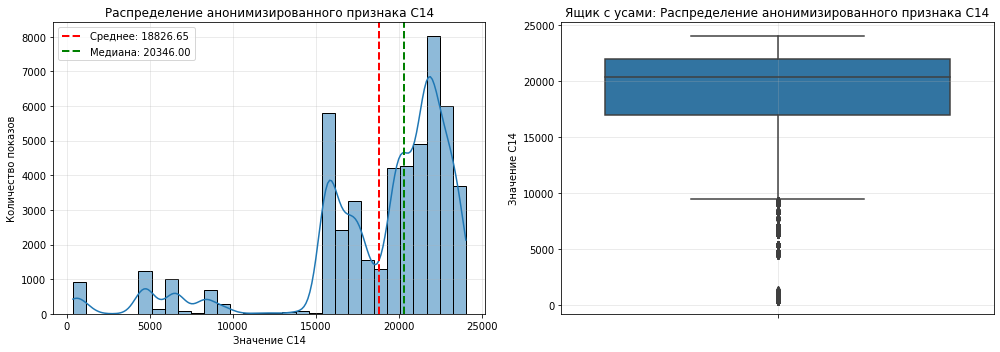

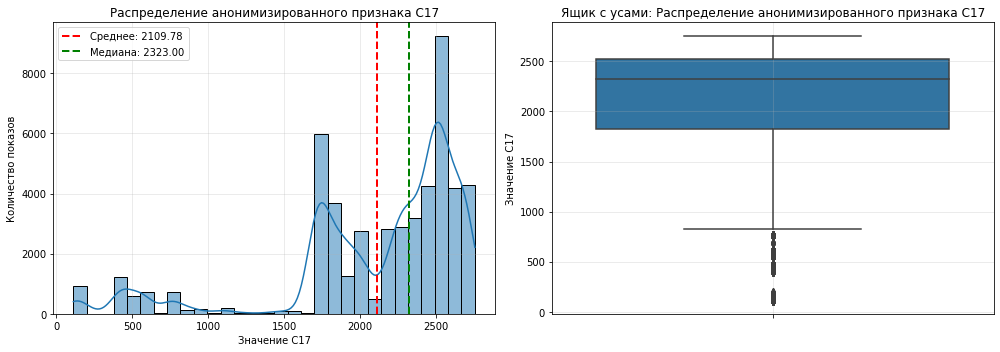

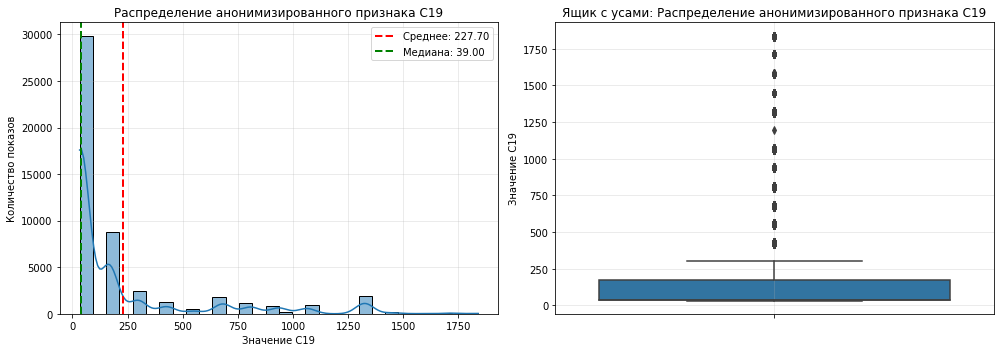

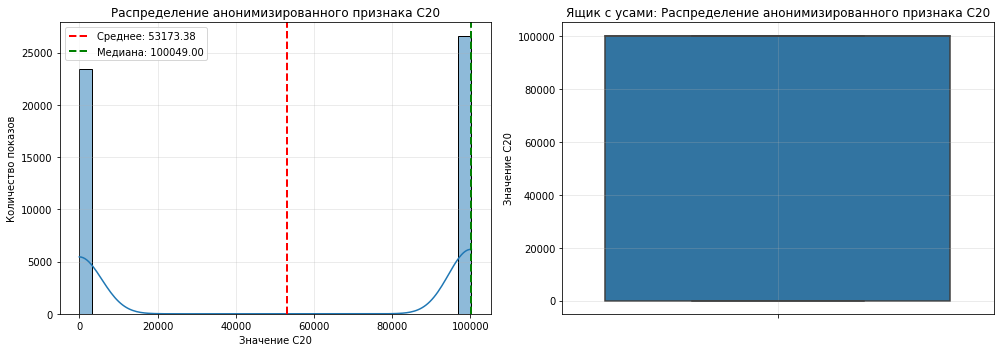

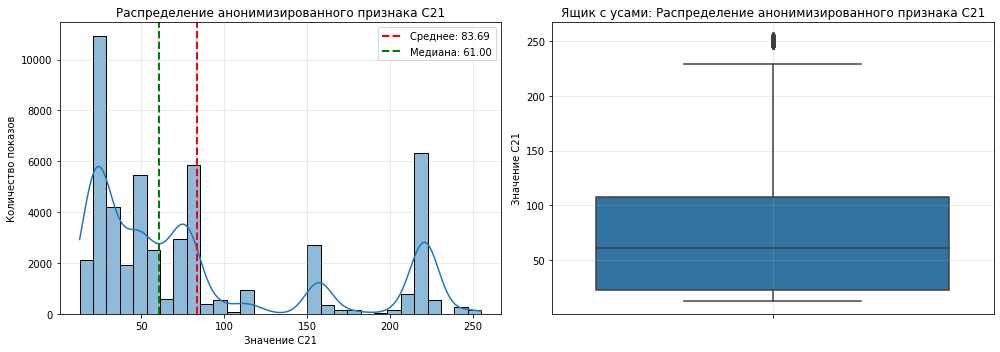

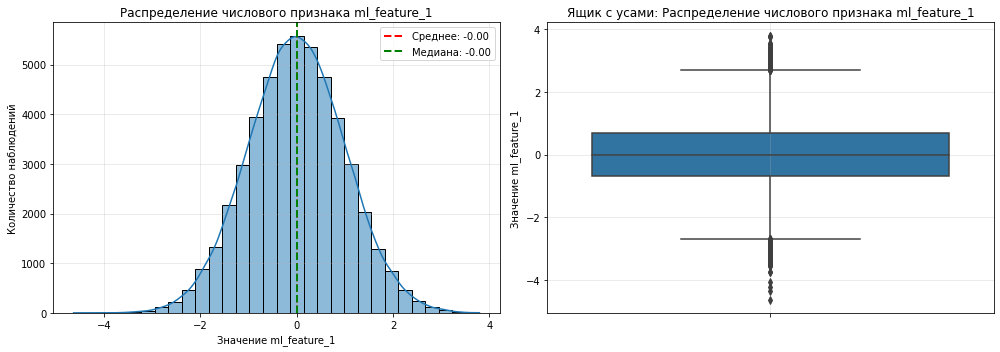

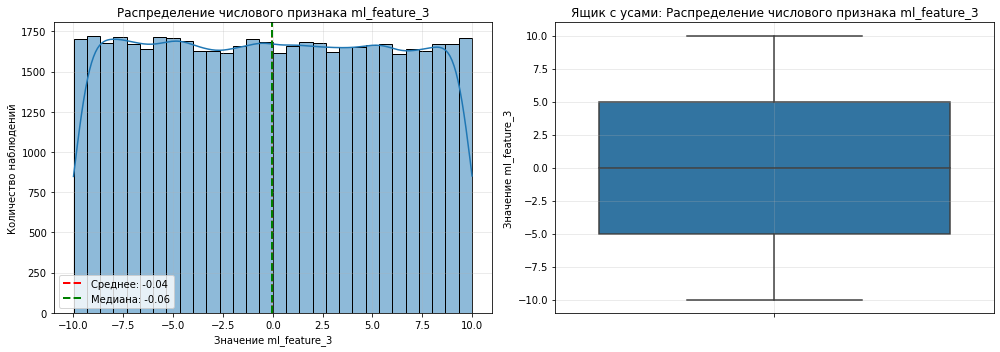

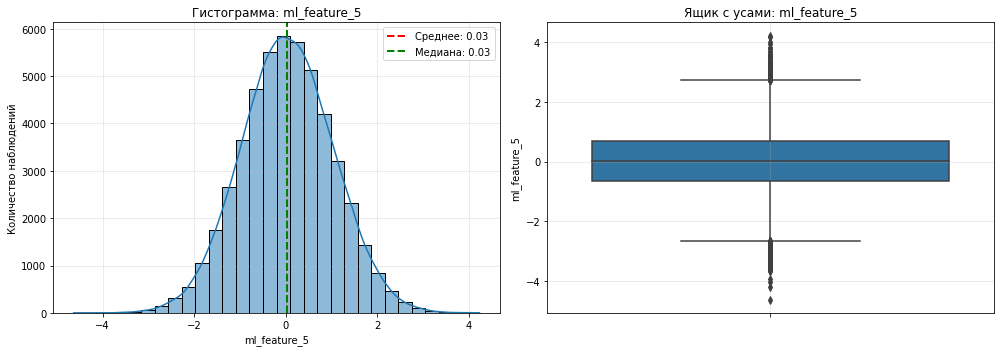

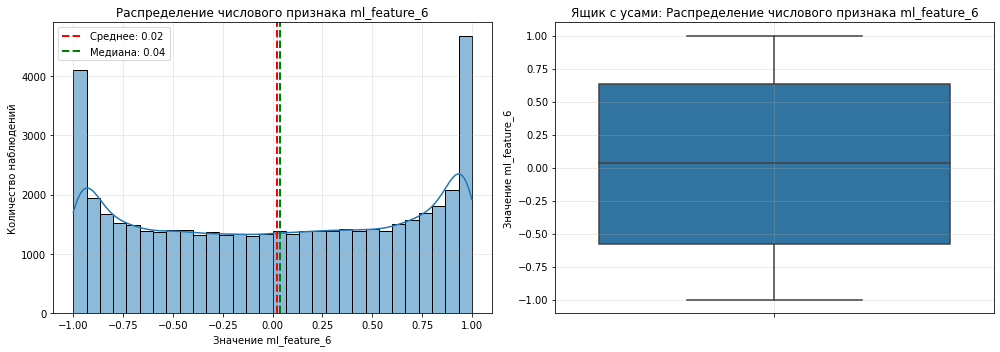

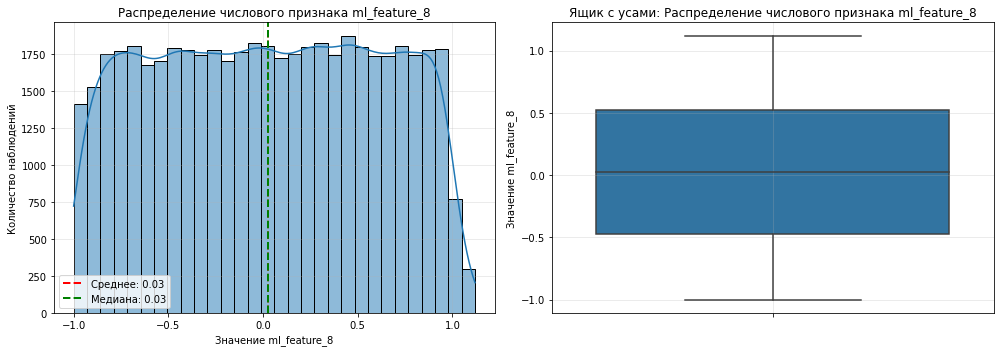

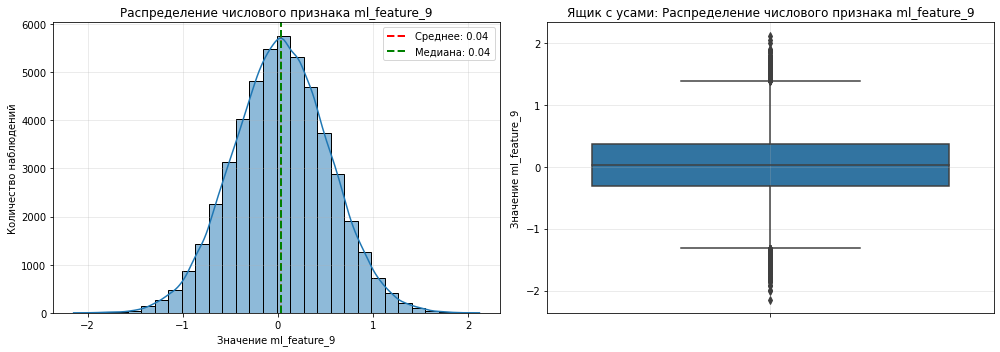

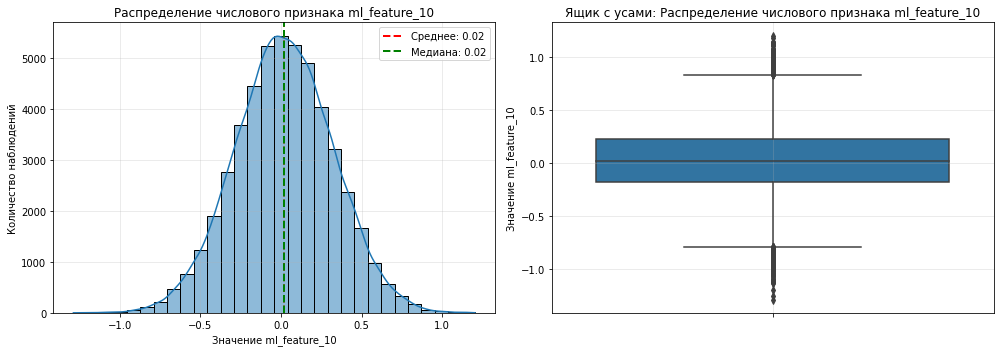

In [20]:
#Гистограммы и boxplot для непрерывных
for column in continuous_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    data = df[column].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    # Гистограмма
    sns.histplot(data, kde=True, bins=30, ax=ax1)
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                label=f'Медиана: {median_val:.2f}')
    
    # Подписи из словаря
    labels = plot_labels.get(column, {})
    ax1.set_title(labels.get('title', f'Гистограмма: {column}'))
    ax1.set_xlabel(labels.get('xlabel', column))
    ax1.set_ylabel(labels.get('ylabel', 'Количество наблюдений'))
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Boxplot
    sns.boxplot(y=data, ax=ax2)
    ax2.set_title(f'Ящик с усами: {labels.get("title", column)}')
    ax2.set_ylabel(labels.get('xlabel', column))
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Почти во всех непрерывных признаках наблюдаются выбросы. В столбцах "C14", "C17", "C19", "C21" они являются относительно нормальными. Тем более, не зная "природу" этих признаков, не буду делать поспешных выводов и удалять их. Распределение признаков ml_feature_число показывает, что их среднее и медиана чаще всего сконцентрированы в нуле, а структура распределения данных очень похожа. Возможно, эти признаки мультиколлинеарны, но это проверим позже. Больше всего вопросов возникате при рассмотрении признака "C20". Большинство его значений располагаются в районе 10000, но также большое количество значений видно около нуля. Посередине данных не наблюдается. Возможно, значение около нуля является заглушкой. Посмотрим на его уникальные значения.

In [21]:
#Уникальные значения C20
df['C20'].unique()

array([    -1, 100084, 100111, 100105, 100037, 100217, 100081, 100077,
       100151, 100083, 100130, 100075, 100119, 100128, 100160, 100101,
       100050, 100034, 100019, 100200, 100046, 100000, 100074, 100079,
       100148, 100029, 100065, 100021, 100210, 100076, 100094, 100171,
       100060, 100020, 100131, 100202, 100055, 100053, 100161, 100001,
       100013, 100215, 100103, 100108, 100233, 100068, 100194, 100028,
       100031, 100182, 100032, 100156, 100117, 100181, 100190, 100170,
       100221, 100166, 100143, 100126, 100090, 100193, 100173, 100141,
       100072, 100097, 100176, 100062, 100043, 100228, 100150, 100191,
       100183, 100005, 100241, 100093, 100199, 100188, 100004, 100144,
       100003, 100024, 100057, 100123, 100106, 100192, 100048, 100189,
       100088, 100052, 100168, 100212, 100172, 100107, 100095, 100063,
       100149, 100087, 100124, 100051, 100061, 100162, 100152, 100070,
       100073, 100177, 100155, 100112, 100039, 100135, 100059, 100113,
      

Так и есть. Все значения меньше 10000 являются заглушкой -1. Судя по графику с заглушкой находится почти половина данных, что делает их почти наполовину синтетическими. Проверим распределение значений.

In [22]:
df['C20'].value_counts()

-1         23443
 100084     3009
 100148     2221
 100111     2110
 100077     1958
           ...  
 100213        2
 100121        2
 100024        1
 100229        1
 100178        1
Name: C20, Length: 149, dtype: int64

Со значением -1 в данных 23443 строк, что почти половина от 50000(всего строк в датасете). Такие данные могут нарушить работу модели, поэтому признак "C20" нужно удалить из датасета.

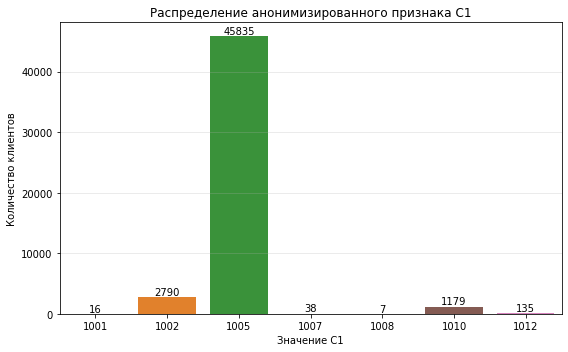

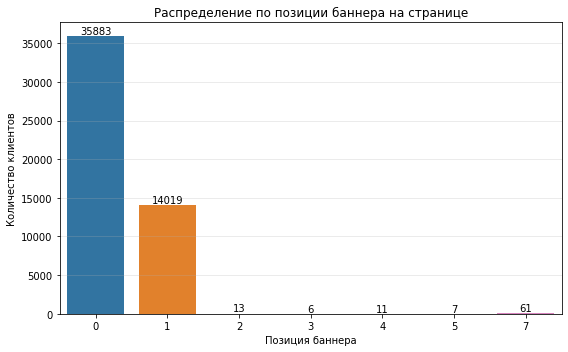

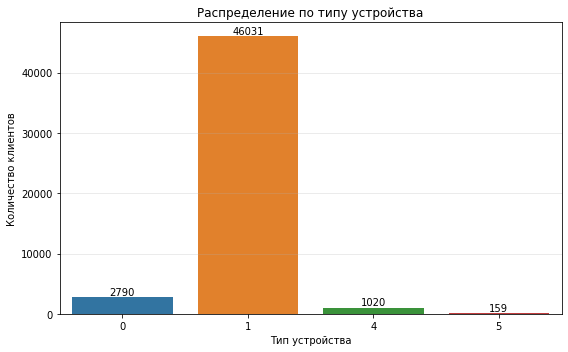

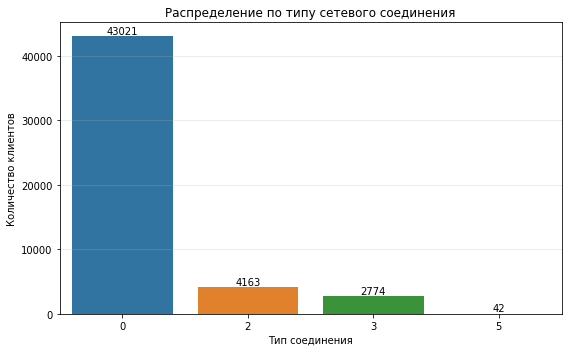

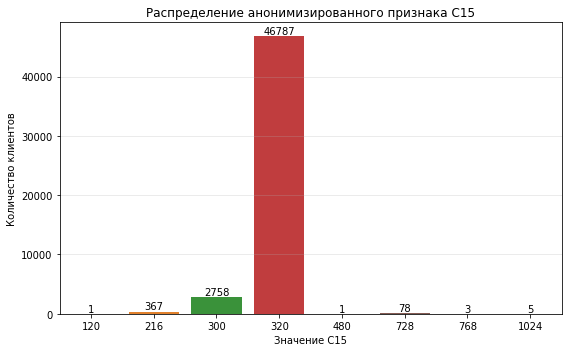

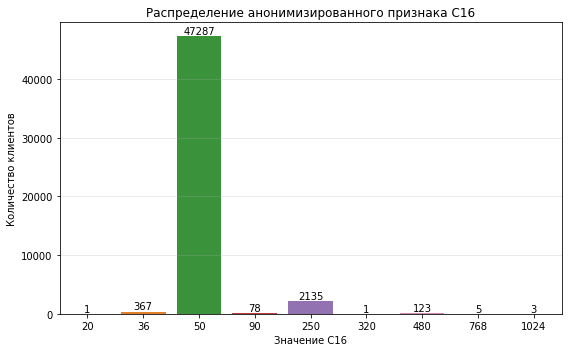

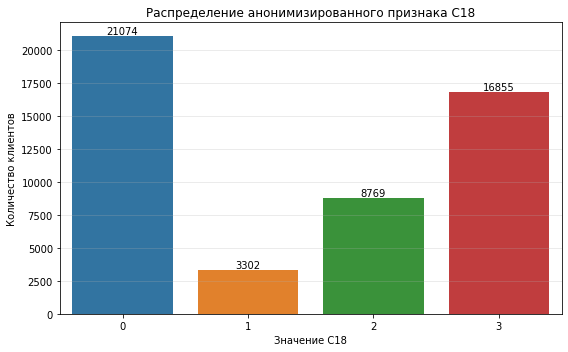

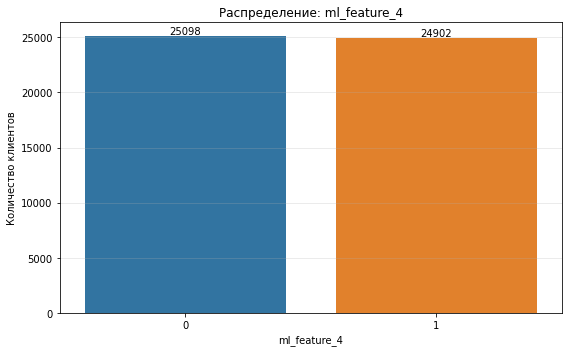

In [23]:
#Countplot для непрерывных
for column in discrete_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    data = df[column].dropna().astype(int)
    labels = plot_labels.get(column, {})
    
    sns.countplot(x=data, ax=ax)
    ax.set_title(labels.get('title', f'Распределение: {column}'))
    ax.set_xlabel(labels.get('xlabel', column))
    ax.set_ylabel('Количество клиентов')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавим значения над столбцами
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

В столбцах "C1", "banner_pos", "device_type", "device_conn_type", "C15"и "C16" явно видно преобладание одного значения над другими. Столбцы "C18" и "ml_feature_4" распределены хорошо.

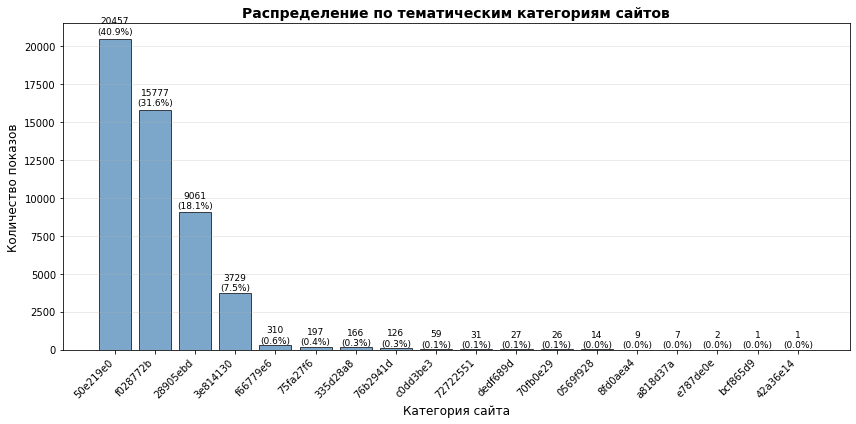

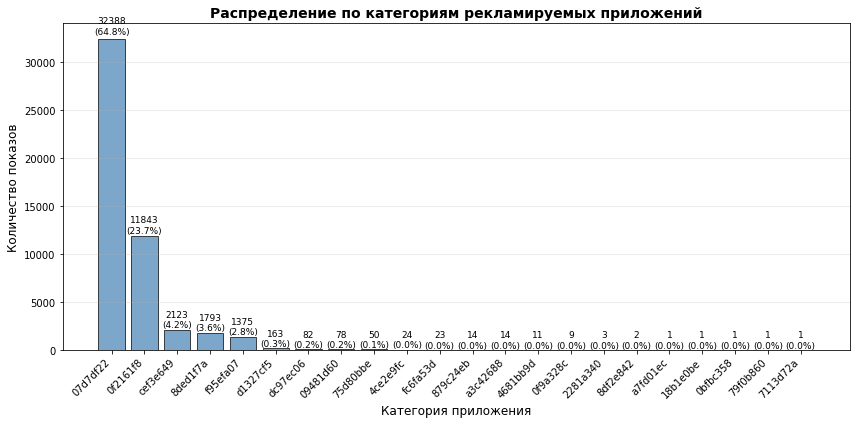

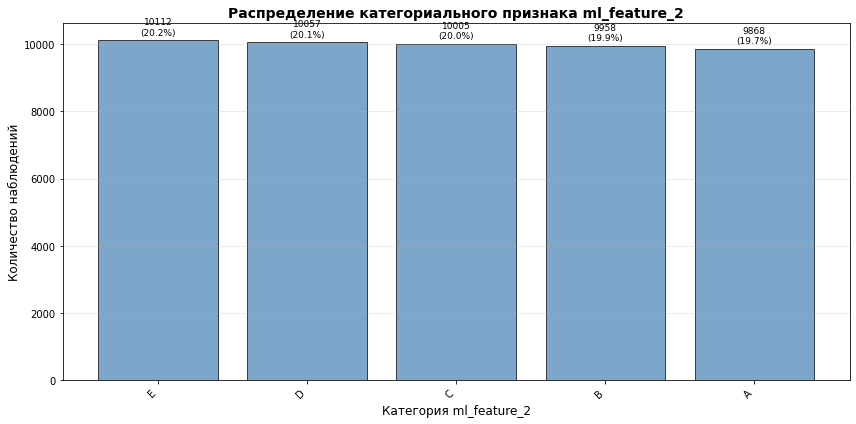

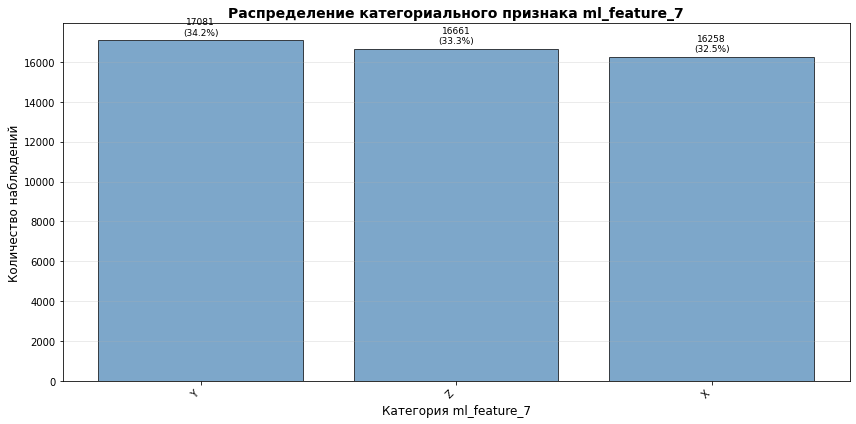

In [24]:
for column in categorical_cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Считаем частоты
    value_counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100
    
    # Строим bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values, 
                  color='steelblue', alpha=0.7, edgecolor='black')
    
    # Добавляем значения и проценты на столбцы
    for i, (count, pct) in enumerate(zip(value_counts.values, percentages.values)):
        ax.text(i, count + (count * 0.01), f'{count}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=9)
        
    labels = plot_labels.get(column, {})
    ax.set_title(labels.get('title', f'Распределение: {column}'), fontsize=14, fontweight='bold')
    ax.set_xlabel(labels.get('xlabel', column), fontsize=12)
    ax.set_ylabel(labels.get('ylabel', 'Количество'), fontsize=12)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

В столбцах "site_category" и "app_category" слишком несбалансированы данные. Один-два столбца заметно преобладают над другими.

**2.8 Корреляции**

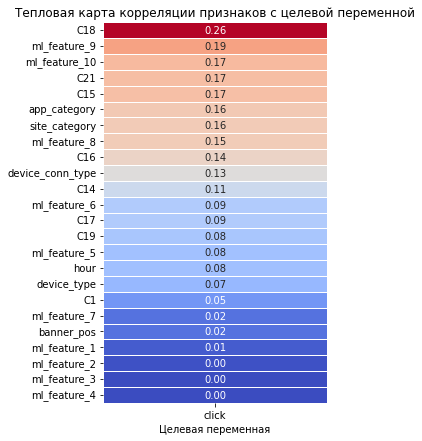

In [25]:
#Построим матрицу корреляции между признаками и целевой переменной
#Задаем интервальные столбцы
interval_cols = ['C14', 'C17', 'C19', 'C21', 'ml_feature_1', 
                 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8',
                'ml_feature_9', 'ml_feature_10']
correlation_matrix = df[['hour', 'C14', 'C1', 'banner_pos', 'device_type','C17', 
                         'C18', 'app_category', 'C19', 'C21', 'ml_feature_1',
                         'ml_feature_3', 'ml_feature_6',
                         'device_conn_type', 'C15', 'C16', 'site_category',
                         'ml_feature_8', 'ml_feature_9', 
                         'ml_feature_10', 'ml_feature_2',
                        'ml_feature_4', 'ml_feature_5', 
                         'ml_feature_7', 'click']].phik_matrix(interval_cols=interval_cols)
#Строим тепловую карту
plt.figure(figsize=(4, 7))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'click'][['click']].sort_values(by='click',
                                                                                                 ascending=False)

sns.heatmap(data_heatmap, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=False)

plt.title('Тепловая карта корреляции признаков с целевой переменной')
plt.xlabel('Целевая переменная')
plt.show()

Самая большая связь у целевой переменной наблюдается с признаком "C18"(0.26). С признаками "ml_feature_2", "ml_feature_3" и "ml_feature_4" взаимосвязь не была найдена вообще.

**2.9 Выводы по EDA**

После проведения исследовательского анализа данных датасет сократился на 3 столбца(осталось 31). Были удалены столбцы, не содержащие важные для модели данные.

В датасете осталось 2 категориальный признак, который нужно будет закодировать с помощью OneHotEncoder, так как в нем немного уникальных значений. А также 7 признаков, которые нужно закодировать с помощью TargetEncoder. Также значения числовых признаков представлены в разных масштабах, поэтому после разделения на выборки их нужно будет стандартизировать. Так как в данных нет пропусков, ничего заполнять не нужно.

На данный момент наиболее важными для модели выглядят признаки "C18", "ml_feature_9" и "ml_feature_10", так как они показали наиболее сильную связь на тепловой карте.

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [26]:
#У столбца hour формат YYMMDDHH, значит последние два значения - это час
df['hour_of_day'] = df['hour'].astype(str).str[-2:].astype(int)

# Циклическое кодирование часа
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

In [27]:
#Поделим данные на выборки

X = df.drop(columns=['click'])
y = df['click']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify=y, shuffle=True,
                                                   random_state=RANDOM_STATE)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

In [28]:
print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер калибровочной выборки: {X_calib.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер обучающей выборки: (30000, 33)
Размер калибровочной выборки: (10000, 33)
Размер тестовой выборки: (10000, 33)


Данные разделены верно.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [29]:
#Числовые признаки
num_values = ['C18', 'ml_feature_9', 'ml_feature_10',
             'C21', 'ml_feature_8', 'C14', 'ml_feature_6',
             'C17', 'C19', 'ml_feature_5', 'hour',
             'ml_feature_1']
#Категориальные признаки с малым количеством значений
cat_values_one_hot = ['ml_feature_7', 'ml_feature_2']

#Категориальные признаки с большим коичеством значений
cat_values_target = ['site_category', 'site_id', 'site_domain', 'app_category', 'app_id', 'app_domain', 'device_model']
#Цикличные признаки часа
cyclic_values = ['hour_sin', 'hour_cos']

In [30]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline_one_hot = Pipeline([
    ('encoding', OneHotEncoder(handle_unknown='error', sparse_output=False, drop='first'))
])

cat_pipeline_target = Pipeline([
    ('encoder', TargetEncoder(random_state=RANDOM_STATE))
])

In [31]:
#Преобрзуем все в общий пайплайн
preprocessor = ColumnTransformer([
    ('num_values', num_pipeline, num_values),
    ('cat_values', cat_pipeline_one_hot, cat_values_one_hot),
    ('cat_values_target', cat_pipeline_target, cat_values_target), 
    ('cyclic', 'passthrough', cyclic_values)
])

X_train_p = preprocessor.fit_transform(X_train, y_train)

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [32]:
#Получаем имена признаков
ohe_features = (
    preprocessor
    .named_transformers_['cat_values']
    .named_steps['encoding']
    .get_feature_names_out(cat_values_one_hot)
)

#Собираем имена в правильном порядке
feature_names = (num_values +
                list(ohe_features) +
                cat_values_target +
                cyclic_values)

#Преобразуем в датафрейм
X_train_df = pd.DataFrame(X_train_p, columns=feature_names)

y_train_series = pd.Series(y_train).reset_index(drop=True)

**5.1 Фильтрационные методы**

In [33]:
#Удалим квази-константные признаки
vs_quasi = VarianceThreshold(threshold=0.01) 
X_train_var = vs_quasi.fit_transform(X_train_df)

features_after_var = X_train_df.columns[vs_quasi.get_support()].tolist()
X_train_df = X_train_df[features_after_var]

print(f'Признаков до VarianceThreshold: {len(feature_names)}')
print(f'Признаков после VarianceThreshold: {len(features_after_var)}\n')

Признаков до VarianceThreshold: 27
Признаков после VarianceThreshold: 23



Так как признаки уже стандартизированы и закодированы, то для порога VarianceThreshold было выбрано достаточн низкое значение - 0.01. После этого этапа осталось 23 признака.

In [34]:
#Считаем корреляцию с целевой переменной
correlation = X_train_df.corrwith(y_train_series).abs().sort_values(ascending=False)

print('Топ-15 признаков по корреляции с целевой переменной:')
print(correlation.head(15))

Топ-15 признаков по корреляции с целевой переменной:
site_id           0.245076
site_domain       0.224450
ml_feature_9      0.148439
ml_feature_10     0.131224
device_model      0.090571
ml_feature_8      0.078346
C21               0.069458
C14               0.066465
ml_feature_5      0.063223
ml_feature_6      0.062309
C17               0.060824
ml_feature_7_Z    0.037090
C18               0.022816
hour              0.017201
ml_feature_7_Y    0.012681
dtype: float64


In [35]:
CORR_THRESHOLD = 0.02

top_corr_features = correlation[correlation > CORR_THRESHOLD].index.tolist()

print(f'Отобрано {len(top_corr_features)} признаков после фильтрации')

Отобрано 13 признаков после фильтрации


Для хорошей работы модели отберем признаки не по количеству, а по их корреляции с целевой переменной. Для таких данных подойдет порог - 0.02. После фильтрационного этапа в данных осталось 13 признаков.

**5.2 Метод-обёртка**

In [36]:
rfe_selector = RFE(estimator=LogisticRegression(random_state=RANDOM_STATE, 
                                                class_weight = 'balanced', 
                                                max_iter=1000, n_jobs=-1), n_features_to_select=15)
rfe_selector.fit(X_train_df, y_train_series)

rfe_features = X_train_df.columns[rfe_selector.support_].tolist()

#Смотрим ранг
rfe_ranking = pd.DataFrame({
    'Признак': X_train_df.columns,
    'Ранг': rfe_selector.ranking_
}).sort_values(by='Ранг')

print(rfe_ranking)

           Признак  Ранг
0              C18     1
18         site_id     1
15  ml_feature_2_C     1
14  ml_feature_2_B     1
13  ml_feature_7_Z     1
19     site_domain     1
9     ml_feature_5     1
20    device_model     1
6     ml_feature_6     1
5              C14     1
4     ml_feature_8     1
3              C21     1
2    ml_feature_10     1
1     ml_feature_9     1
7              C17     1
12  ml_feature_7_Y     2
16  ml_feature_2_D     3
8              C19     4
10            hour     5
21        hour_sin     6
17  ml_feature_2_E     7
11    ml_feature_1     8
22        hour_cos     9


После применения метода обертки мы можем видеть, какие признаки решила оставить модель.

**5.3 Финальный набор признаков**

In [37]:
#Находим пересечение
final_features = list(set(top_corr_features).intersection(set(rfe_features)))
print(f'Итоговое количество признаков: {len(final_features)}')
print('Финальный набор признаков:')
for feat in final_features:
    print(f' - {feat}')
    
X_train_final = X_train_df[final_features]

Итоговое количество признаков: 13
Финальный набор признаков:
 - ml_feature_9
 - C18
 - site_id
 - ml_feature_10
 - C14
 - ml_feature_5
 - device_model
 - ml_feature_8
 - ml_feature_7_Z
 - site_domain
 - C17
 - ml_feature_6
 - C21


Далее соединяем выбранные признаки после фильтрационного метода и обертки, и получаем финальный набор признаков.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

**6.1 Dummy модель**

In [38]:
#Строим модель Dummy
dummy_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', rfe_selector),
    ('model', DummyClassifier(strategy='stratified'))
])

N_FOLDS = 5

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = ['average_precision', 'neg_brier_score', 'precision', 'recall', 'f1']

dummy_cv = cross_validate(dummy_pipeline,
                       X_train, y_train, scoring=scoring,
                       cv=kfold, return_train_score=False,
                       n_jobs=-1, error_score='raise')

dummy_means = {
    'PR-AUC':dummy_cv['test_average_precision'].mean(),
    'Brier Score': -dummy_cv['test_neg_brier_score'].mean(),
    'Precision': dummy_cv['test_precision'].mean(),
    'Recall': dummy_cv['test_recall'].mean(),
    'F1': dummy_cv['test_f1'].mean()
}

print('Результат Dummy:')
print(f'PR-AUC: {dummy_means["PR-AUC"]:.4f}')
print(f'Brier Score: {dummy_means["Brier Score"]:.4f}')
print(f'Precision: {dummy_means["Precision"]:.4f}')
print(f'Recall: {dummy_means["Recall"]:.4f}')
print(f'F1: {dummy_means["F1"]:.4f}')

Результат Dummy:
PR-AUC: 0.1720
Brier Score: 0.2851
Precision: 0.1709
Recall: 0.1664
F1: 0.1686


Модель Dummy показывает 0.173 на метрике PR-AUC, это будет нашей отправной точкой при построении следующих моделей. Precision у базовой модели составляет 0.1663, Recall - 0.1682, F1 - 0.1672.

**6.2 LogisticRegression**

In [39]:
#Строим LogisticRegression
lg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', rfe_selector),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lg_cv = cross_validate(lg_pipeline,
                       X_train, y_train, scoring=scoring,
                       cv=kfold, return_train_score=False,
                       n_jobs=-1, error_score='raise')

lg_means = {
    'PR-AUC':lg_cv['test_average_precision'].mean(),
    'Log loss': -lg_cv['test_neg_brier_score'].mean(),
    'Precision': lg_cv['test_precision'].mean(),
    'Recall': lg_cv['test_recall'].mean(),
    'F1': lg_cv['test_f1'].mean()
}

print('Результат Logistic Regression:')
print(f'PR-AUC: {lg_means["PR-AUC"]:.4f}')
print(f'Brier Score: {lg_means["Log loss"]:.4f}')
print(f'Precision: {lg_means["Precision"]:.4f}')
print(f'Recall: {lg_means["Recall"]:.4f}')
print(f'F1: {lg_means["F1"]:.4f}')

Результат Logistic Regression:
PR-AUC: 0.3992
Brier Score: 0.1242
Precision: 0.6136
Recall: 0.1191
F1: 0.1995


Логистическая регрессия показывает лучше результаты на PR-AUC по сравнению с базовой моделью (0.3992 > 0.173). Однако смотря на Recall можно сказать, что модель достаточно плохо находит положительный класс, что крайне важно для данной бизнес-задачи. Построим еще одну модель.

**6.3 SVC**

In [40]:
import warnings
warnings.filterwarnings('ignore')

#Построим модель SVC
svc_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', rfe_selector),
    ('model', SVC(kernel='linear', probability=False, random_state=RANDOM_STATE))
])

# Получаем предсказания через кросс-валидацию
y_pred_class = cross_val_predict(svc_pipeline, X_train, y_train, 
                                 cv=kfold, method='predict', n_jobs=-1)

y_pred_decision = cross_val_predict(svc_pipeline, X_train, y_train, 
                                    cv=kfold, method='decision_function', n_jobs=-1)

# Считаем метрики
pr_auc = average_precision_score(y_train, y_pred_decision)
precision = precision_score(y_train, y_pred_class, zero_division=0)
recall = recall_score(y_train, y_pred_class, zero_division=0)

print('Результат SVC:')
print(f'PR-AUC: {pr_auc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

Результат SVC:
PR-AUC: 0.3216
Precision: 0.0000
Recall: 0.0000


Код с SVC показывает результаты 0.3216 на PR-AUC, однако совершенно не находит положительный класс.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [41]:
#Задаем параметрическую сетку
param_grid_svc = {
    'model__kernel': ['rbf', 'linear'],
    'model__C': [0.1, 1],
    'model__gamma': ['scale'],
    'model__class_weight': ['balanced']
}
    
param_grid_lg = {
    'model__C': [0.1, 1],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}

In [42]:
#Grid для Logistic Regression
grid_lg = GridSearchCV(estimator=lg_pipeline,
                      param_grid = param_grid_lg,
                      cv=3,
                      scoring=scoring,
                      refit='average_precision',
                      n_jobs=-1,
                      verbose=2)
grid_lg.fit(X_train, y_train)

best_params_lg = grid_lg.best_params_

best_estimator_lg = grid_lg.best_estimator_

best_score_lg = round(grid_lg.best_score_, 3)

print("Лучшие гиперпараметры:", best_params_lg)
print("Лучшая модель:", best_estimator_lg)
print("Лучший средний результат PR-AUC на кросс-валидации:", best_score_lg)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__C=0.1, model__penalty=l1, model__solver=liblinear; total time=  28.7s
[CV] END model__C=0.1, model__penalty=l1, model__solver=liblinear; total time=  29.8s
[CV] END model__C=0.1, model__penalty=l1, model__solver=liblinear; total time=  27.8s
[CV] END model__C=0.1, model__penalty=l1, model__solver=saga; total time=  29.1s
[CV] END model__C=0.1, model__penalty=l1, model__solver=saga; total time=  29.7s
[CV] END model__C=0.1, model__penalty=l1, model__solver=saga; total time=  28.8s
[CV] END model__C=0.1, model__penalty=l2, model__solver=liblinear; total time=  31.4s
[CV] END model__C=0.1, model__penalty=l2, model__solver=liblinear; total time=  29.3s
[CV] END model__C=0.1, model__penalty=l2, model__solver=liblinear; total time=  29.3s
[CV] END model__C=0.1, model__penalty=l2, model__solver=saga; total time=  29.7s
[CV] END model__C=0.1, model__penalty=l2, model__solver=saga; total time=  30.0s
[CV] END model__C=0

После применения GridSearchCV на модели логистической регрессии лучшей комбинацией оказалась версия с C=0.1, penalty=L2, solver=saga. Однако модель все еще показывает не высокие результаты, всего 0.39 на PR-AUC

In [43]:
#Grid для SVC
scoring_svc = ['average_precision', 'precision', 'recall', 'f1']

grid_svc = GridSearchCV(estimator=svc_pipeline,
                      param_grid = param_grid_svc,
                      cv=3,
                      scoring=scoring_svc,
                      refit='average_precision',
                      n_jobs=-1,
                      verbose=2)
grid_svc.fit(X_train, y_train)

best_params_svc = grid_svc.best_params_

best_estimator_svc = grid_svc.best_estimator_

best_score_svc = round(grid_svc.best_score_, 3)

print("Лучшие гиперпараметры:", best_params_svc)
print("Лучшая модель:", best_estimator_svc)
print("Лучший средний результат PR-AUC на кросс-валидации:", best_score_svc)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf; total time=  59.2s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf; total time=  59.7s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf; total time=  58.5s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=  48.1s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=  48.2s
[CV] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=linear; total time=  47.6s
[CV] END model__C=1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf; total time=  58.3s
[CV] END model__C=1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf; total time=  59.0s
[CV] END model__C=1, model__class_weight=balanc

После применения GridSearch лучшей моделью оказалась с линейным ядром, C=0.1, gamma=scale, class_weight=balanced. PR-AUC у лучшей модели = 0.388. Эти показатели меньше, чем у LogisticRegression, поэтому выбираем именно регрессию.

In [44]:
#Создаем таблицу с лучшими результатами по LogisticRegresion
results_lg = pd.DataFrame(grid_lg.cv_results_)

# Сортируем по PR-AUC (test_average_precision) и берем топ-10
top10_lg = results_lg.sort_values('mean_test_average_precision', ascending=False).head(10)

# Выбираем нужные колонки для отображения
columns_to_show = [
    'params',
    'mean_test_average_precision',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1',
    'rank_test_average_precision'
]

# Создаем таблицу
top10_lg_display = top10_lg[columns_to_show].copy()

top10_lg_display.columns = [
    'Параметры',
    'PR-AUC',
    'Precision',
    'Recall',
    'F1-score',
    'Ранг'
]

# Округляем числовые значения
numeric_cols = ['PR-AUC', 'Precision', 'Recall', 'F1-score']
for col in numeric_cols:
    top10_lg_display[col] = top10_lg_display[col].round(4)

print(top10_lg_display.to_string(index=True))

                                                                 Параметры  PR-AUC  Precision  Recall  F1-score  Ранг
3       {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'saga'}  0.3900     0.6181  0.0974    0.1682     1
2  {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}  0.3896     0.6209  0.0940    0.1631     2
7         {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'saga'}  0.3889     0.5949  0.1155    0.1931     3
6    {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}  0.3888     0.5959  0.1147    0.1920     4
4    {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}  0.3884     0.5907  0.1153    0.1926     5
0  {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}  0.3884     0.6125  0.1062    0.1807     6
5         {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'saga'}  0.3884     0.5915  0.1157    0.1931     7
1       {'model__C': 0.1, 'model__penalty': 'l1', 'model

По топ-10 видно, что лучшая модель по PR-AUC имеет значение 0.3900, для дальнейшего обучения выбираем ее.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [45]:
#Обучаем финальную модель на всей выборке
best_estimator_lg.fit(X_train, y_train)

y_pred_test = best_estimator_lg.predict(X_test)
y_pred_proba_test = best_estimator_lg.predict_proba(X_test)[:, 1]

test_pr_auc = average_precision_score(y_test, y_pred_proba_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)
test_brier = brier_score_loss(y_test, y_pred_proba_test)

print("Оценка на тестовых данных:")
print(f"PR-AUC: {test_pr_auc:.4f}")
print(f"Brier score: {test_brier:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")

Оценка на тестовых данных:
PR-AUC: 0.3970
Brier score: 0.1248
Precision: 0.6272
Recall: 0.1017
F1-score: 0.1750


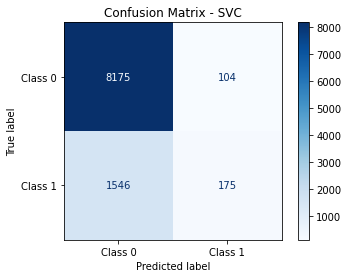

In [46]:
#Построим матрицу ошибок
cm = confusion_matrix(y_test, y_pred_test)

# Визуализируем
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVC')
plt.show()

На тестовых данных модель показывает средний уровень, однако стабильный. Она плохо находит положительный класс, то есть находит лишь 10% всех положительных объектов, лишь 62% предсказанных положительных объектов действительно положительны. Это говорит о том, что модель ошибается и маркирует ложноотрицательные объекты. Матрица ошибок подтверждает данную гипотезу. Однако высокая оценка Бриера говорит о том, что модель неправильно предсказывает свои вероятности, и ее нужно откалибровать.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

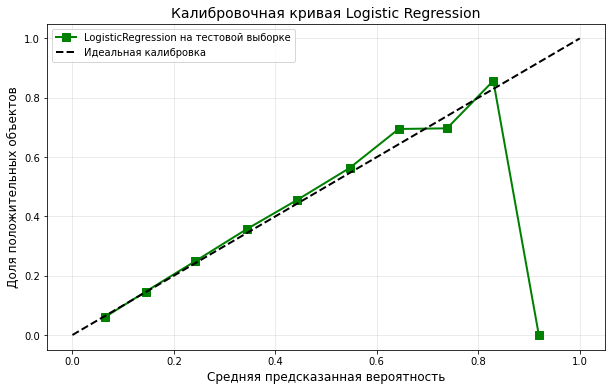

In [47]:
#Проверим текущую калибровку модели
y_proba_lg = best_estimator_lg.predict_proba(X_test)[:, 1]

# Строим калибровочную кривую
prob_true, prob_pred = calibration_curve(y_test, y_proba_lg, n_bins=10)

# Визуализация
plt.figure(figsize=(10, 6))

plt.plot(prob_pred, prob_true, 
         marker='s', linewidth=2, markersize=8,
         label='LogisticRegression на тестовой выборке', color='green')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Идеальная калибровка')

plt.xlabel('Средняя предсказанная вероятность', fontsize=12)
plt.ylabel('Доля положительных объектов', fontsize=12)
plt.title('Калибровочная кривая Logistic Regression', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Калибровочная кривая говорит о том, что модель хорошо предсказывает вероятности выше нуля, но на нуле дает аномально высокие значения.

In [48]:
# Трансформируем данные
X_calib_p = preprocessor.transform(X_calib)
X_test_p = preprocessor.transform(X_test)

best_model = best_estimator_lg.named_steps['model']

base_lg = LogisticRegression(
    C=best_model.C,
    penalty=best_model.penalty,
    solver=best_model.solver,
    max_iter=best_model.max_iter,
    random_state=RANDOM_STATE)

# Обучаем на тренировочных данных
base_lg.fit(X_train_p, y_train)

# Внутренний kfold для калибровки
inner_kfold = StratifiedKFold(n_splits=3,
                             shuffle=True,
                             random_state=4242)

# Создаем калиброванную модель
calibrated_model = CalibratedClassifierCV(
    estimator=base_lg,
    method='isotonic',
    cv=inner_kfold
)

# Обучаем на калибровочной выборке
calibrated_model.fit(X_calib_p, y_calib)

# Предсказываем вероятности на тестовой выборке
y_calibrated_proba = calibrated_model.predict_proba(X_test_p)[:, 1]

# Оценка Бриера
brier_score_calibrated = brier_score_loss(y_test, y_calibrated_proba)

print(f"Оценка Бриера для калиброванной модели: {brier_score_calibrated:.4f}")

y_original_proba = best_estimator_lg.predict_proba(X_test)[:, 1]
brier_score_original = brier_score_loss(y_test, y_original_proba)
print(f"Оценка Бриера для исходной модели: {brier_score_original:.4f}")

Оценка Бриера для калиброванной модели: 0.1260
Оценка Бриера для исходной модели: 0.1248


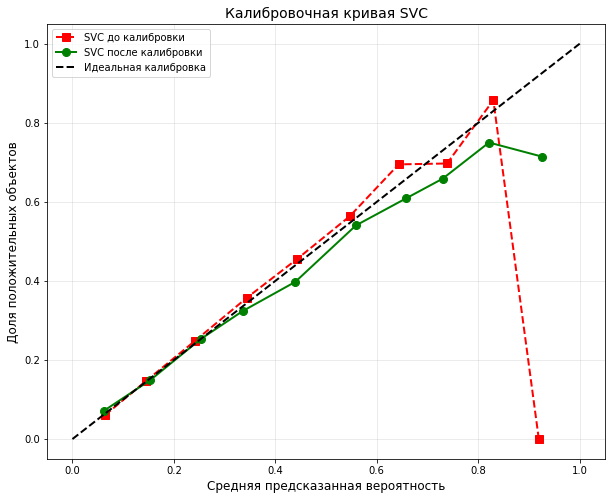

In [49]:
#Стрим калибровочную кривую после калибровки
# После калибровки
y_proba_after = calibrated_model.predict_proba(X_test_p)[:, 1]

#Строим калибровочную кривую
# n_bins=10 - количество бинов для группировки вероятностей
prob_true_after, prob_pred_after = calibration_curve(y_test, y_proba_after, n_bins=10)

#Визуализация
plt.figure(figsize=(10, 8))

#Кривая до калибровки
plt.plot(prob_pred, prob_true, 
         marker='s', linewidth=2, markersize=8,
         label='SVC до калибровки', color='red', linestyle='--')

#Кривая после калибровки
plt.plot(prob_pred_after, prob_true_after, 
         marker='o', linewidth=2, markersize=8,
         label='SVC после калибровки', color='green')

# Идеально калиброванная модель
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Идеальная калибровка')

plt.xlabel('Средняя предсказанная вероятность', fontsize=12)
plt.ylabel('Доля положительных объектов', fontsize=12)
plt.title('Калибровочная кривая SVC', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

После калибровки модели оценка Бриера стала хуже, но на графике мы можем видеть, что предсказания модели стали намного стабильнее. Теперь она не предсказывает высокие значения для нулевых вероятностей.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [50]:
#Функция ECE
def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            distribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += distribution
    return ece / n

#Функция MCE
def calculate_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    max_error = 0
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            diff = np.abs(bin_conf - bin_acc)
            max_error = max(max_error, diff)
    return max_error

In [51]:
# Данные для модели до калибровки
brier_before = brier_score_loss(y_test, y_proba_lg)
ece_before = calculate_ece(y_test, y_proba_lg)
mce_before = calculate_mce(y_test, y_proba_lg)

# Данные для модели после калибровки
y_proba_after = calibrated_model.predict_proba(X_test_p)[:, 1]

brier_after = brier_score_loss(y_test, y_proba_after)
ece_after = calculate_ece(y_test, y_proba_after)
mce_after = calculate_mce(y_test, y_proba_after)

# Результаты
results = pd.DataFrame({
    'Модель': ['LogisticRegression до калибровки', 'LogisticRegression после калибровки'],
    'Brier Score': [brier_before, brier_after],
    'ECE': [ece_before, ece_after],
    'MCE': [mce_before, mce_after]
})

results['Brier Score'] = results['Brier Score'].round(4)
results['ECE'] = results['ECE'].round(4)
results['MCE'] = results['MCE'].round(4)

print(results.to_string(index=False))

                             Модель  Brier Score    ECE    MCE
   LogisticRegression до калибровки       0.1248 0.0055 0.9194
LogisticRegression после калибровки       0.1260 0.0091 0.2116


После калибровки оценка Бриера немного повысилась, что говорит о небольшом ухудшении прогнозируемых вероятностей. Метка ECE была немного ближе к нулю до калибровки, чем после нее, что также говорит о небольшом ухудшении. Однако метрика MCE очень сильно уменьшиласт, что мы могли уже увидеть на графике. Получается, что в самой наихудшей точке предсказанные вероятности отличаются на 0.2116, что достаточно неплохо для модели, которая до этого ошибалась максимум на 0.9194.

In [52]:
#Посмотрим на метрики модели после калибровки
y_pred_cal = calibrated_model.predict(X_test_p)

test_pr_auc_after = average_precision_score(y_test, y_proba_after)
test_precision_after = precision_score(y_test, y_pred_cal)
test_recall_after = recall_score(y_test, y_pred_cal)
test_f1_after = f1_score(y_test, y_pred_cal)

print("Оценка на тестовых данных:")
print(f"PR-AUC: {test_pr_auc_after:.4f}")
print(f"Precision: {test_precision_after:.4f}")
print(f"Recall: {test_recall_after:.4f}")
print(f"F1-score: {test_f1_after:.4f}")

Оценка на тестовых данных:
PR-AUC: 0.3865
Precision: 0.5804
Recall: 0.1511
F1-score: 0.2397


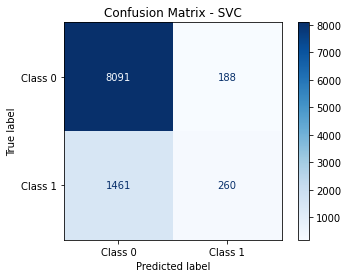

In [53]:
#Построим матрицу ошибок
cm = confusion_matrix(y_test, y_pred_cal)

# Визуализируем
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVC')
plt.show()

После проведения калибровки можно утверждать, что модель немного лучше находит положительный класс, но все еще делает ложноотрицательные ошибки. Это означает, что она требует сильной доработки.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

In [54]:
# Сводная таблица характеристик
feature_names_full = []

# Для числовых признаков
feature_names_full.extend(num_values)

# Для OneHotEncoder (категориальные признаки с малым количеством значений)
feature_names_full.extend(
    preprocessor.named_transformers_['cat_values']
    .named_steps['encoding']
    .get_feature_names_out(cat_values_one_hot)
)

# Для TargetEncoder (категориальные признаки с большим количеством значений)
# TargetEncoder не меняет названия признаков
feature_names_full.extend(cat_values_target)

# Для циклических признаков
feature_names_full.extend(cyclic_values)

coef_lg = best_estimator_lg.named_steps['model'].coef_[0]

# Получаем коэффициенты модели
coef_lg = best_estimator_lg.named_steps['model'].coef_[0]

# Получаем маску отобранных признаков из RFE
rfe_selector = best_estimator_lg.named_steps['feature_selection']
selected_mask = rfe_selector.get_support()

# Применяем маску к названиям признаков
selected_feature_names = [name for name, selected in zip(feature_names_full, selected_mask) if selected]

# Создаем DataFrame с важностью признаков
feature_importance = pd.DataFrame({
    'Признак': selected_feature_names,
    'Коэффициент': coef_lg,
    '|Коэффициент|': np.abs(coef_lg)
}).sort_values('|Коэффициент|', ascending=False)

# Топ-5 признаков
top5_features = feature_importance.head(5).copy()
top5_features['Коэффициент'] = top5_features['Коэффициент'].round(4)

# Сводная таблица характеристик моделей
summary_table = pd.DataFrame({
    'Модель': [
        'Dummy Classifier (baseline)',
        'LogisticRegression до калибровки',
        'LogisticRegression после калибровки'
    ],
    'PR-AUC': [
        round(dummy_means["PR-AUC"], 4),
        round(test_pr_auc, 4),
        round(test_pr_auc_after, 4)
    ],
    'Precision': [
        round(dummy_means["Precision"], 4),
        round(test_precision, 4),
        round(test_precision_after, 4)
    ],
    'Recall': [
        round(dummy_means["Recall"], 4),
        round(test_recall, 4),
        round(test_recall_after, 4)
    ],
    'F1-Score': [
        round(dummy_means["F1"], 4),
        round(test_f1, 4),
        round(test_f1_after, 4)
    ],
    'Brier Score': [
        round(dummy_means["Brier Score"], 4),
        round(brier_before, 4),
        round(brier_after, 4)
    ]
})

print('\nСводная таблица характеристик моделей')
print(summary_table.to_string(index=False))


Сводная таблица характеристик моделей
                             Модель  PR-AUC  Precision  Recall  F1-Score  Brier Score
        Dummy Classifier (baseline)  0.1720     0.1709  0.1664    0.1686       0.2851
   LogisticRegression до калибровки  0.3970     0.6272  0.1017    0.1750       0.1248
LogisticRegression после калибровки  0.3865     0.5804  0.1511    0.2397       0.1260


In [55]:
print('Таблица сравнения до и после калибровки')
print(results.to_string(index=False))

Таблица сравнения до и после калибровки
                             Модель  Brier Score    ECE    MCE
   LogisticRegression до калибровки       0.1248 0.0055 0.9194
LogisticRegression после калибровки       0.1260 0.0091 0.2116


In [56]:
print('Таблица 5 самых важных признаков')
print(top5_features[['Признак', 'Коэффициент']].to_string(index=False))

top5_dict = top5_features[['Признак', 'Коэффициент']].to_dict('records')

Таблица 5 самых важных признаков
     Признак  Коэффициент
     site_id       2.6430
      app_id       2.6086
 site_domain       1.4862
  app_domain       1.0323
device_model       0.8434


Метрики итоговой модели превосходят базовую по всем значениям, кроме Recall, однако она не является главной метрикой. Больше всего на вероятность клика влияют app_id, site_id, app_domain, site_domain, device_model. Модель yt хорошо откалибрована. Модель не готова к использованию в продакшене, так как имеет очень плохие показатели и требует доработки.

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [57]:
date = datetime.now().strftime("%Y%m%d")
version = "1.0"

full_model_name = f"full_model_artifact_v{version}_{date}.pkl"

full_artifact = {
    'preprocessor': preprocessor,
    'calibrated_model': calibrated_model,
    'final_model': best_estimator_lg,
    'metadata': {
        'model_version': version,
        'training_date': datetime.now().strftime("%d.%m.%Y"),
        'model_type': 'LogisticRegression',
        'hyperparameters': {
            'C': best_estimator_lg.named_steps['model'].C,
            'penalty': best_estimator_lg.named_steps['model'].penalty,
            'solver': best_estimator_lg.named_steps['model'].solver,
            'max_iter': best_estimator_lg.named_steps['model'].max_iter,
            'random_state': best_estimator_lg.named_steps['model'].random_state
        },
        'features': num_values + cat_values_one_hot + cat_values_target + cyclic_values,
        'performance': {'pr_auc_before_calibration': float(test_pr_auc),
        'pr_auc_after_calibration': float(test_pr_auc_after),
        'brier_before_calibration': float(brier_before),
        'brier_after_calibration': float(brier_after),
        'precision_before_calibration': float(test_precision),
        'precision_after_calibration': float(test_precision_after),
        'recall_before_calibration': float(test_recall),
        'recall_after_calibration': float(test_recall_after),
        'f1_before_calibration': float(test_f1),
        'f1_after_calibration': float(test_f1_after)},
        'feature_importance': top5_dict
    }
}

joblib.dump(full_artifact, full_model_name)

['full_model_artifact_v1.0_20260415.pkl']

In [58]:
loaded_artifact = joblib.load(full_model_name)

# Извлекаем компоненты
loaded_preprocessor = loaded_artifact['preprocessor']
loaded_calibrated_model = loaded_artifact['calibrated_model']
loaded_svc_model = loaded_artifact['final_model']
loaded_metadata = loaded_artifact['metadata']
    
new_sample = {
    'C18': 678,
    'ml_feature_9': 75,
    'ml_feature_10': 45,
    'C21': 30,
    'ml_feature_8': 60,
    'C14': 20,
    'ml_feature_6': 8,
    'C17': 25,
    'C19': 35,
    'ml_feature_5': 5,
    'hour': 2015081021,
    'ml_feature_1': 3,
    'ml_feature_7': 'Y',
    'ml_feature_2': 'C',
    'site_category': 'f21bc',
    'site_id': 'fgh456',
    'site_domain': 'fgh76',
    'app_category': 'fghj74',
    'app_id': 'rty657',
    'app_domain': 'rdvcb76',
    'device_model': 'hjfkdn87',
    'hour_sin': 11,
    'hour_cos':12
}

new_sample_df = pd.DataFrame([new_sample])

new_sample_processed = loaded_preprocessor.transform(new_sample_df)

# Предсказание
prediction = loaded_calibrated_model.predict(new_sample_processed)[0]
probability = loaded_calibrated_model.predict_proba(new_sample_processed)[0, 1]

print(f"Предсказанный класс: {prediction}")
print(f"Вероятность класса 1: {probability:.4f}")
print(f"Вероятность класса 0: {1 - probability:.4f}")

Предсказанный класс: 0
Вероятность класса 1: 0.0000
Вероятность класса 0: 1.0000


Модель успешно сохранена!